## Measure Day 0 (exploring setup)

**Date: 21/09/2026**
**Time: 13.45 - 17.45**

In [98]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path

In [ ]:
import pandas as pda

In [100]:
def detect_red_point(frame):
    """
    Detect the largest red blob in the frame and return its centroid (x, y).
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no red object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Red wraps around in HSV, so use two ranges
    lower_red1 = np.array([0, 80, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 80, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = cv2.bitwise_or(mask1, mask2)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)
    cv2.drawContours(annotated, [largest], -1, (255, 0, 0), 2)
    cv2.putText(
        annotated,
        f"({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [101]:
def detect_green_point(frame):
    """
    Detect the largest green blob in the frame and return its centroid (x, y).
    Returns:
        (x, y, mask, annotated_frame)
        x, y are None if no green object is detected.
    """
    annotated = frame.copy()

    # Convert to HSV for robust color thresholding
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Green HSV range
    lower_green = np.array([35, 80, 50])
    upper_green = np.array([85, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Clean up mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None, None, mask, annotated

    # Pick largest contour
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # Ignore tiny detections
    if area < 10:
        return None, None, mask, annotated

    # Calculate centroid
    M = cv2.moments(largest)

    if M["m00"] == 0:
        return None, None, mask, annotated

    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

    # Draw detected point
    cv2.circle(annotated, (cx, cy), 6, (0, 255, 0), -1)

    cv2.drawContours(
        annotated,
        [largest],
        -1,
        (255, 0, 0),
        2
    )

    cv2.putText(
        annotated,
        f"({cx}, {cy})",
        (cx + 10, cy - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    return cx, cy, mask, annotated

In [102]:
def process_video(video_path, output_csv, preview=True, save_annotated=False):
    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = None

    if save_annotated:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        annotated_path = video_path.with_name(
            video_path.stem + "_tracked.mp4"
        )
        writer = cv2.VideoWriter(
            str(annotated_path),
            fourcc,
            fps,
            (width, height)
        )

    results = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # Detect RED point
        x_red, y_red, mask_red, annotated_red = detect_red_point(frame)

        # Detect GREEN point
        x_green, y_green, mask_green, annotated_green = detect_green_point(frame)

        # Start with original frame
        annotated = frame.copy()

        # Draw red detection
        if x_red is not None and y_red is not None:
            cv2.circle(
                annotated,
                (x_red, y_red),
                6,
                (0, 255, 0),
                -1
            )

        # Draw green detection
        if x_green is not None and y_green is not None:
            cv2.circle(
                annotated,
                (x_green, y_green),
                6,
                (255, 0, 255),
                -1
            )

        time_s = frame_idx / fps if fps > 0 else np.nan

        results.append({
            "frame": frame_idx,
            "time_s": time_s,
            "x_red": x_red,
            "y_red": y_red,
            "x_green": x_green,
            "y_green": y_green
        })

        # Save annotated video
        if writer is not None:
            writer.write(annotated)

        # Preview
        if preview:
            mask_red_bgr = cv2.cvtColor(
                mask_red,
                cv2.COLOR_GRAY2BGR
            )

            mask_green_bgr = cv2.cvtColor(
                mask_green,
                cv2.COLOR_GRAY2BGR
            )

            top = np.hstack((frame, annotated))
            bottom = np.hstack((mask_red_bgr, mask_green_bgr))

            display = np.vstack((top, bottom))

            scale = 0.4
            display = cv2.resize(
                display,
                None,
                fx=scale,
                fy=scale
            )

            cv2.imshow(
                "Original | Red + Green / Masks",
                display
            )

            key = cv2.waitKey(1) & 0xFF

            if key == ord("q"):
                break

        frame_idx += 1

    cap.release()

    if writer is not None:
        writer.release()

    cv2.destroyAllWindows()

    # Save results
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)

    print(f"Done. Saved coordinates to: {output_csv}")

    if save_annotated:
        print(f"Saved annotated video to: {annotated_path}")

    # Missing detections
    missing_red = df["x_red"].isna().sum()
    missing_green = df["x_green"].isna().sum()

    print(f"Frames processed: {len(df)}")
    print(f"Frames with missing red detection: {missing_red}")
    print(f"Frames with missing green detection: {missing_green}")

In [103]:

video = "21092026contrast.mp4"
output = "21092026contrast.csv"

process_video(
        video_path=video,
        output_csv=output,
        preview=True,
        save_annotated=True
    )



Done. Saved coordinates to: 21092026contrast.csv
Saved annotated video to: 21092026contrast_tracked.mp4
Frames processed: 816
Frames with missing red detection: 0
Frames with missing green detection: 214


In [104]:
def export_first_frame(
    video_path,
    output_png=None,
    dpi=300
):
    """
    Export the first frame of a video as a PNG.

    The exported image keeps exactly the same pixel width and height
    as the original video frame.

    Parameters
    ----------
    video_path : str or Path
        Path to the input video.

    output_png : str or Path, optional
        Output PNG path. If None, the output name will be:
        <video_name>_first_frame.png

    dpi : float
        DPI metadata written to the PNG.
        DPI does not change the number of pixels or image quality.
    """

    video_path = Path(video_path)

    if not video_path.exists():
        raise FileNotFoundError(
            f"Video file not found: {video_path}"
        )

    if output_png is None:
        output_png = video_path.with_name(
            video_path.stem + "_first_frame.png"
        )
    else:
        output_png = Path(output_png)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    success, frame = cap.read()
    cap.release()

    if not success or frame is None:
        raise RuntimeError(
            "Could not read the first frame from the video."
        )

    height, width = frame.shape[:2]

    # OpenCV writes the original pixel data without resizing.
    success = cv2.imwrite(
        str(output_png),
        frame,
        [cv2.IMWRITE_PNG_COMPRESSION, 3]
    )

    if not success:
        raise RuntimeError(
            f"Could not save PNG: {output_png}"
        )

    # OpenCV does not reliably write DPI metadata, so add it using Pillow.
    try:
        from PIL import Image

        with Image.open(output_png) as image:
            image.save(
                output_png,
                dpi=(dpi, dpi)
            )

    except ImportError:
        print(
            "Pillow is not installed, so DPI metadata was not added."
        )
        print(
            "Install it with: pip install pillow"
        )

    print(f"Saved first frame to: {output_png}")
    print(f"Resolution: {width} x {height} pixels")
    print(f"DPI metadata: {dpi} DPI")

    return output_png

In [105]:
export_first_frame(
    video_path=video,
    output_png="20260710_141408_first_frame.png",
    dpi=300
)

Saved first frame to: 20260710_141408_first_frame.png
Resolution: 1920 x 1080 pixels
DPI metadata: 300 DPI


WindowsPath('20260710_141408_first_frame.png')

# Data Analysis

In [106]:
x_pivot = 995
y_pivot = 206

In [111]:
import numpy as np

data = np.genfromtxt(
    "21092026_2.csv",
    delimiter=",",
    skip_header=1
)

# Extract coordinates
time = data[:, 1]

x_red = data[:, 2]
y_red = data[:, 3]

x_green = data[:, 4]
y_green = data[:, 5]

# Keep only rows where BOTH red and green coordinates are present
mask = (
    ~np.isnan(x_red) &
    ~np.isnan(y_red) &
    ~np.isnan(x_green) &
    ~np.isnan(y_green)
)

# Apply mask
time = time[mask]

x_red = x_red[mask]
y_red = y_red[mask]

x_green = x_green[mask]
y_green = y_green[mask]

# Shift coordinates relative to the pivots
x_red_shifted = x_red - x_pivot
y_red_shifted = y_red - y_pivot

x_green_shifted = x_green - x_pivot
y_green_shifted = y_green - y_pivot

In [108]:
import matplotlib.pyplot as plt

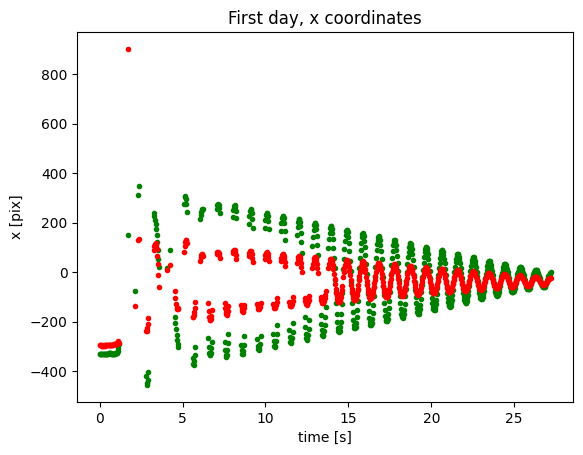

In [115]:
plt.figure()
plt.title("First day, x coordinates")
plt.plot(time,x_green_shifted,"g.")
plt.plot(time,x_red_shifted,"r.")
plt.xlabel("time [s]")
plt.ylabel("x [pix]")

plt.show()

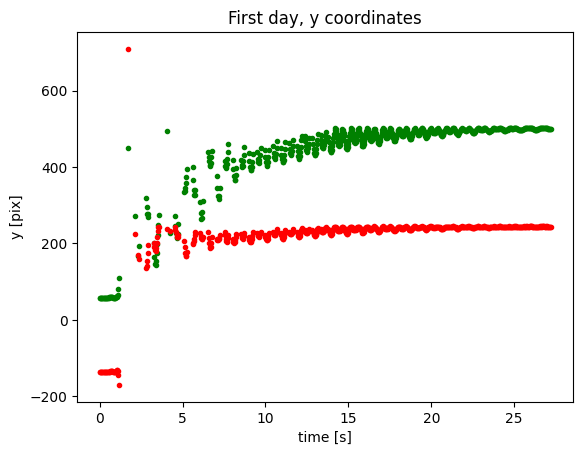

In [114]:
plt.figure()
plt.title("First day, y coordinates")
plt.plot(time,y_green_shifted,"g.")
plt.plot(time,y_red_shifted,"r.")
plt.xlabel("time [s]")
plt.ylabel("y [pix]")

plt.show()

## Measure Day 1

**Date: 05/10/2026**  
**Time: 13.45 - 17.45**  

**Research question:**  How does the initial gravitational potential energy $E_0$ of a double pendulum affect the finite-time exponential divergence rate $\lambda$  of nearby trajectories?  
**Assumptions:** The initial kinetic energy of the double pendulum is neglected, because the pendulum is released from rest.  
**Hypothesis**:  At lower initial gravitational potential energy, the double pendulum remains close to the small-angle regime where its equations of motion are lineair and the motion approximately harmonic. As this initial energy increases, the small angle approximation becomes invalid and nonlineair effects become more important. We therefore expect finite time exponential divergence rate to increase with initial gravitational potential energy.  
**Measuring Setup:**  
**Measuring Plan:**  
- Measure the pendulums lengths L1 and L2
- measure the pendulum masses m1 and m2
- mark the center of masses with distinguishable red and green markers. 
- place the camera parallel to the plane of motion
- fix the camera for the entire experiment and note its settings
- test that the motion of the pendulum stays inside the video frame  

Repeat the following measurements for initial angles of $\theta_1$ = 10 $^{\circ}$, 20 $^{\circ}$  ,30 $^{\circ}$  ,40 $^{\circ}$  ,50 $^{\circ}$  ,60 $^{\circ}$    and $\theta_2$ = 0 $^{\circ}$

- place the pendulum in the first initial position
- let the pendulum come to rest
- start recording while still holding the pendulum without blocking the markers
- record the release from rest out of this initial condition
- stop the recording. Later, extract the actual initial angles from the first video frames
- place the pendulum in the same initial condition with an increase of $\theta_1$ equal to 3 degrees
- record the release from rest again
- import these files into python
- run the tracking code and check that the markers have been tracked correctly
- repeat all steps with an increase in initial angles  
- *make repeated measurements for each initial state*  
 **Data Analysis Procedure**: 

In [ ]:
import cv2 # opencv-python
import numpy as np
from pathlib import Path
import pandas as pda